# Лабораторная работа: MLflow и предсказание массы пингвинов
В данной работе мы используем датасет `penguins`, проводим трекинг экспериментов в MLflow и подготавливаем модель к развертыванию.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from mlflow.models import infer_signature
import matplotlib.pyplot as plt

print("MLflow Version:", mlflow.__version__)

MLflow Version: 3.11.1


## 1. Загрузка и предобработка данных

In [2]:
# Загружаем датасет
df = sns.load_dataset('penguins')

# Очистка данных
df = df.dropna()

# Кодирование категориальных признаков
le = LabelEncoder()
for col in ['species', 'island', 'sex']:
    df[col] = le.fit_transform(df[col])

X = df.drop('body_mass_g', axis=1)
y = df['body_mass_g']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,1
1,0,2,39.5,17.4,186.0,3800.0,0
2,0,2,40.3,18.0,195.0,3250.0,0
4,0,2,36.7,19.3,193.0,3450.0,0
5,0,2,39.3,20.6,190.0,3650.0,1


## 2. Проведение экспериментов (Tracking)

In [5]:
def run_penguin_experiment(n_estimators, max_depth, run_name):
    mlflow.set_experiment("Penguin_Research")
    
    with mlflow.start_run(run_name=run_name):
        model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        
        # Метрики
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        # Логирование
        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2", r2)
        
        signature = infer_signature(X_train, model.predict(X_train))
        mlflow.sklearn.log_model(model, "model", signature=signature)
        
        print(f"Run {run_name}: R2={r2:.3f}")

# Запускаем разные конфигурации
run_penguin_experiment(1, 1, "Underfit_Model") 
run_penguin_experiment(20, 3, "Medium_Model")
run_penguin_experiment(500, 20, "Optimal_Model")

/home/koluchiy/anaconda3/envs/mlflow/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/15 01:01:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 01:01:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires

Run Underfit_Model: R2=0.675


/home/koluchiy/anaconda3/envs/mlflow/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/15 01:02:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 01:02:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires

Run Medium_Model: R2=0.873


/home/koluchiy/anaconda3/envs/mlflow/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/15 01:02:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 01:02:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires

Run Optimal_Model: R2=0.865


## 3. Анализ результатов

Лучшая модель: Medium_Model
ID запуска для деплоя: a37bc6c889ab45ef81c68586fe6cc27e


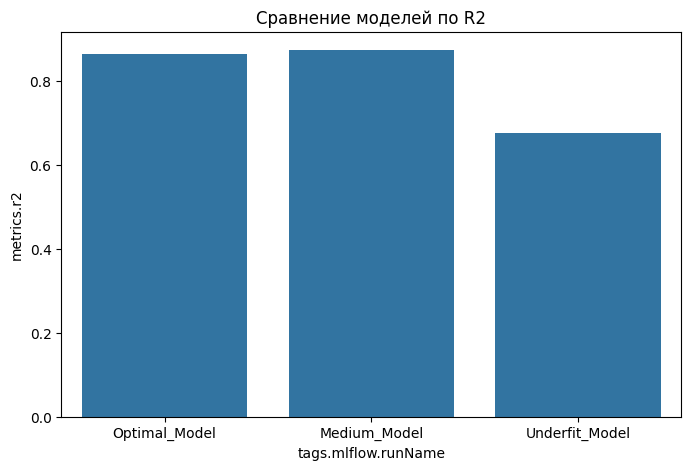

In [7]:
# Поиск лучшей модели
runs = mlflow.search_runs(experiment_names=["Penguin_Research"])
best_run = runs.sort_values("metrics.r2", ascending=False).iloc[0]

print(f"Лучшая модель: {best_run['tags.mlflow.runName']}")
print(f"ID запуска для деплоя: {best_run['run_id']}")

# Визуализация
plt.figure(figsize=(8, 5))
sns.barplot(x="tags.mlflow.runName", y="metrics.r2", data=runs)
plt.title("Сравнение моделей по R2")
plt.show()

## 4. Команды для развертывания

```bash
mlflow models serve -m runs:/MODEL_ID/model -p 5001 --env-manager local
```